In [1]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand
from george.modeling import Model
from george import kernels, GP
from scipy.optimize import minimize
from time import time

# %matplotlib widget
# plt.close('all')

## Load dataset

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


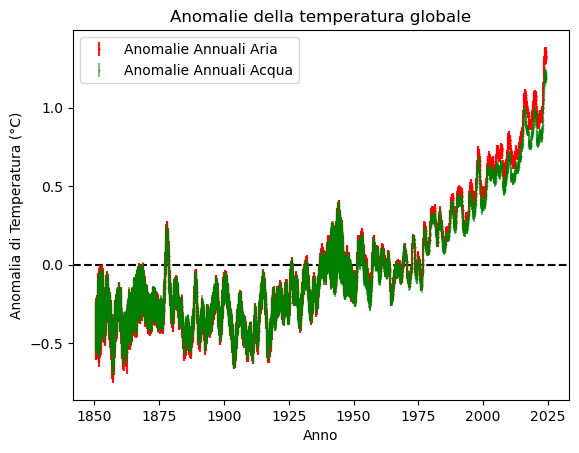

In [2]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

plt.Figure(figsize=(10, 6))
plt.errorbar(data_air['time_years'], data_air['Annual_Anomaly'], yerr=data_air['Annual_Anomaly_Unc'], fmt='.r', markersize=1, zorder=1, alpha=0.9, label='Anomalie Annuali Aria')
plt.errorbar(data_water['time_years'], data_water['Annual_Anomaly'], yerr=data_water['Annual_Anomaly_Unc'], fmt='.g', markersize=1, zorder=2, alpha=0.5, label='Anomalie Annuali Acqua')
plt.xlabel('Anno')
plt.ylabel('Anomalia di Temperatura (°C)')
plt.title('Anomalie della temperatura globale')
plt.axhline(0, color='black', linestyle='--', zorder=0)
plt.legend()
plt.show()

## Models definition

In [3]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [4]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 10 - 5

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 10
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = cube[0] * 2 - 1
    params[1] = cube[1] * 10 - 5
    params[2] = cube[2] * 10 - 5

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = cube[2] * 10 - 5
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

## Ultranest 

In [5]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-8e+04  -81416.72 [-81416.7252..-81416.7251]*| it/evals=4560/5118 eff=96.6511% N=400 0   0  
[ultranest] Likelihood function evaluations: 5136
[ultranest]   logZ = -8.142e+04 +- 0.09984
[ultranest] Effective samples strategy satisfied (ESS = 1257.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.11, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.10 tail:0.04 total:0.11 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -81424.954 +- 0.232
  single instance: logZ = -81424.954 +- 0.139
  bootstrapped   : logZ = -81424.941 +- 0.229
  tail           : logZ = +- 0.039
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3449│ ▁  ▁▁▁▁▁▁▂▂▂▂▄▅▃▆▆▇▇▇▅▅▅▅▃▃▂▂▁▁▁▁▁▁▁▁ │0.3530    0.3492 +- 0.0010

STARTING RUN: WATER_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+04  -74211.44 [-74211.4406..-74211.4406]*| it/evals=4520/5065 eff=96.8917% N=400 0   0  
[ultranest] Likelihood function evaluations: 5088
[ultranest]   logZ = -7.422e+04 +- 0.1227
[ultranest] Effective samples strategy satisfied (ESS = 1239.0, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.12 tail:0.04 total:0.13 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -74219.579 +- 0.311
  single instance: logZ = -74219.579 +- 0.139
  bootstrapped   : logZ = -74219.552 +- 0.309
  tail           : logZ = +- 0.039
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.31538│ ▁▁▁▁▁▁▁▁▁▂▂▄▃▅▄▅▆▇▇▇▆▅▄▄▃▂▂▁▁▁▁▁▁▁  ▁ │0.32329    0.31923 +- 0.00095

STARTING RUN: AIR_LINEAR
[ultranest] Sampling 400 live points from prior ...

[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6253..-20185.6253]*| it/evals=9880/13524 eff=75.2819% N=400    0   0 
[ultranest] Likelihood function evaluations: 13534
[ultranest]   logZ = -2.021e+04 +- 0.1598
[ultranest] Effective samples strategy satisfied (ESS = 1589.3, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.12 to 0.60, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -20205.737 +- 0.599
  single instance: logZ = -20205.737 +- 0.219
  bootstrapped   : logZ = -20205.697 +- 0.599
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009890│ ▁   ▁▁▁▁▁▁▁▁▂▂▃▃▅▇▇▇▇▇▇▆▅▄▄▂▂▁▁▁▁▁▁▁▁ │0.010132    0.010024 +- 0.000028
    b                   : -0.9824│ ▁▁▁▁▁

[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8236..-18230.8235]*| it/evals=10080/13541 eff=76.7065% N=400   0   0  
[ultranest] Likelihood function evaluations: 13591
[ultranest]   logZ = -1.825e+04 +- 0.1535
[ultranest] Effective samples strategy satisfied (ESS = 1627.9, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -18251.505 +- 0.313
  single instance: logZ = -18251.505 +- 0.222
  bootstrapped   : logZ = -18251.528 +- 0.313
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009019│ ▁▁ ▁▁▁▁▁▁▁▁▂▂▃▄▅▆▇▇▇▇▇▆▅▄▃▄▂▂▁▁▁▁▁▁▁▁ │0.009254    0.009145 +- 0.000027
    b                   : -0.9110│ ▁ ▁▁▁▁▁▁▁▂▂▄▄▅▅▆▇▇▆▆▅▃▃▂▁▁▁▁▁▁▁▁

[ultranest] Explored until L=-2e+03  138.32 [-2138.3880..-2138.3880]*| it/evals=15440/29433 eff=53.1809% N=400    0   00  00  
[ultranest] Likelihood function evaluations: 29502
[ultranest]   logZ = -2172 +- 0.2543
[ultranest] Effective samples strategy satisfied (ESS = 1875.9, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.19 to 0.70, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.25 tail:0.01 total:0.25 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -2172.435 +- 0.546
  single instance: logZ = -2172.435 +- 0.285
  bootstrapped   : logZ = -2172.465 +- 0.545
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00009961│ ▁▁▁▁▁▁▁▁▁▂▂▃▄▄▆▆▆▇▇▇▆▅▆▅▅▄▃▂▁▁▁▁▁▁▁▁▁ │0.00010457    0.00010215 +- 0.00000062
    b                   : -0.01195│

[ultranest] Explored until L=-2e+03  948.94 [-1948.9952..-1948.9950]*| it/evals=15570/29882 eff=52.8119% N=400    0    0  0  
[ultranest] Likelihood function evaluations: 29918
[ultranest]   logZ = -1983 +- 0.2117
[ultranest] Effective samples strategy satisfied (ESS = 1893.5, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.16 to 0.63, need <0.5)
[ultranest]   logZ error budget: single: 0.29 bs:0.21 tail:0.01 total:0.21 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -1983.345 +- 0.365
  single instance: logZ = -1983.345 +- 0.287
  bootstrapped   : logZ = -1983.392 +- 0.365
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00008702│ ▁  ▁▁▁▁▁▁▁▁▁▂▃▅▅▆▇▇▇▇▇▆▆▅▄▃▂▁▁▁▁▁▁▁▁▁ │0.00009204    0.00008970 +- 0.00000058
    b                   : -0.01023

[ultranest] Explored until L=-2e+03  681.17 [-1681.2242..-1681.2241]*| it/evals=10600/114648 eff=9.2781% N=400   0   0   0 
[ultranest] Likelihood function evaluations: 114720
[ultranest]   logZ = -1703 +- 0.186
[ultranest] Effective samples strategy satisfied (ESS = 1867.8, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.15 to 0.67, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.19 tail:0.01 total:0.19 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -1703.180 +- 0.339
  single instance: logZ = -1703.180 +- 0.226
  bootstrapped   : logZ = -1703.267 +- 0.339
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.02914│ ▁ ▁▁▁▁▁▁▁▁▂▂▂▃▅▆▆▇▇▇▇▇▆▆▅▃▂▃▂▁▁▁▁▁▁▁▁ │0.03718    0.03338 +- 0.00095
    b                   : 0.02151│ ▁▁▁▁▁▁▁▂▂▃▄▄▆

[ultranest] Explored until L=-2e+03  687.33 [-1687.3850..-1687.3848]*| it/evals=10640/111418 eff=9.5840% N=400   0  00   0 
[ultranest] Likelihood function evaluations: 111486
[ultranest]   logZ = -1709 +- 0.1774
[ultranest] Effective samples strategy satisfied (ESS = 1900.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.18, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.18 tail:0.01 total:0.18 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -1709.447 +- 0.408
  single instance: logZ = -1709.447 +- 0.227
  bootstrapped   : logZ = -1709.394 +- 0.408
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0313│ ▁▁▁▁▁▁▁▁▂▂▃▃▅▆▆▇▇▇▆▆▅▅▄▃▃▂▂▁▁▁▁▁▁▁ ▁▁ │0.0398    0.0353 +- 0.0011
    b                   : 0.02051│ ▁ ▁▁▁▁▁▁▁▂▂▃▃▄▅▅▆▇▇▇▇▆▆▄▄▂▂▂▁▁▁▁▁▁▁▁▁ │0.021

## Constant fit

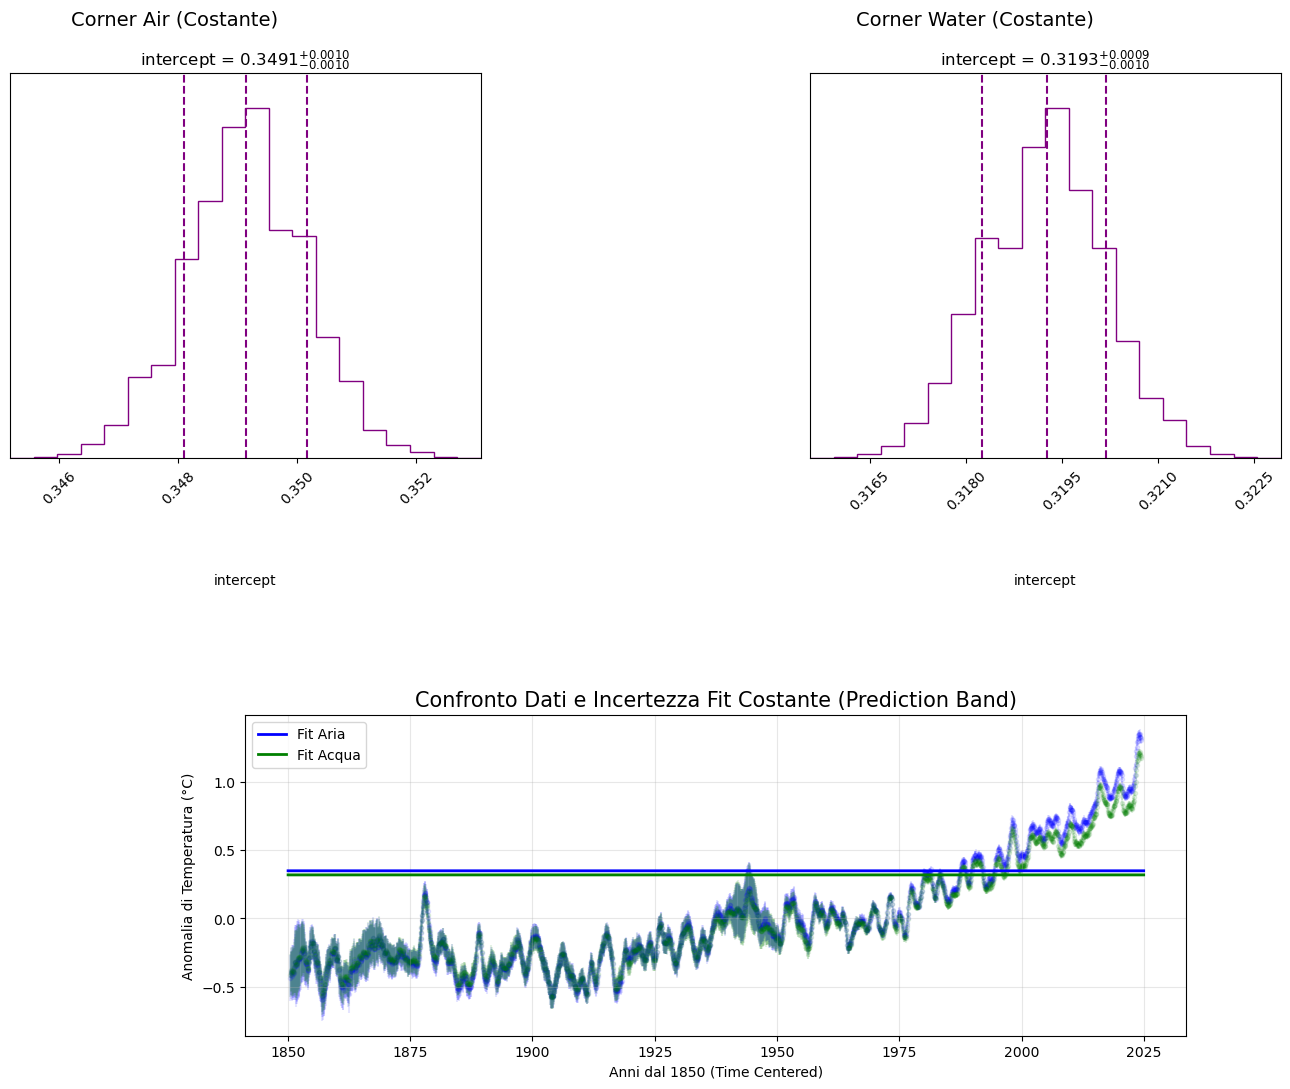

In [13]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_years'].min(), data_water['time_years'].min())
t_max = max(data_air['time_years'].max(), data_water['time_years'].max())
t_grid = np.linspace(t_min, t_max, 2088)

def add_constant_band(ax, res_key, data, color, label_name):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid)

    for val in samples:
        band.add(np.full_like(t_grid, val))
    
    ax.errorbar(data['time_years'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_name}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Linear fit

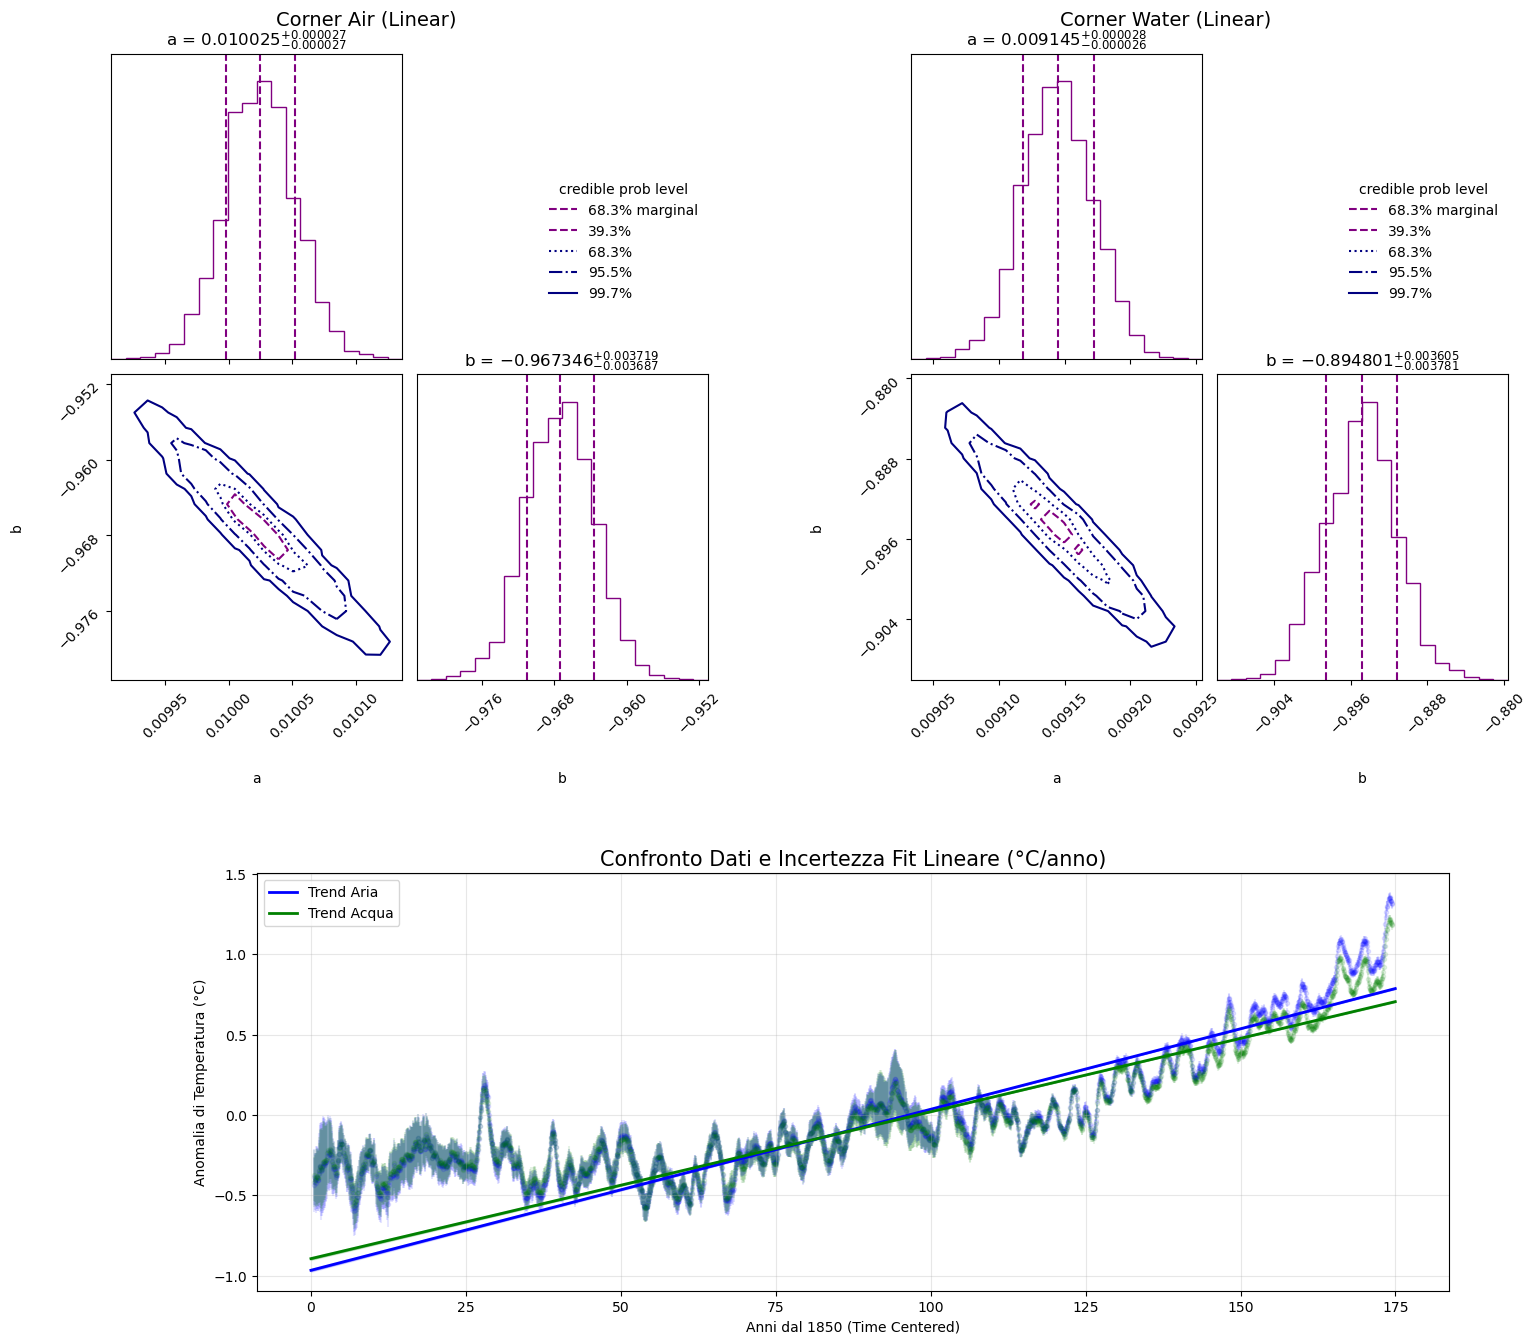

In [7]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b in samples:
        band.add(a * t_grid + b)
        
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Quadratic fit

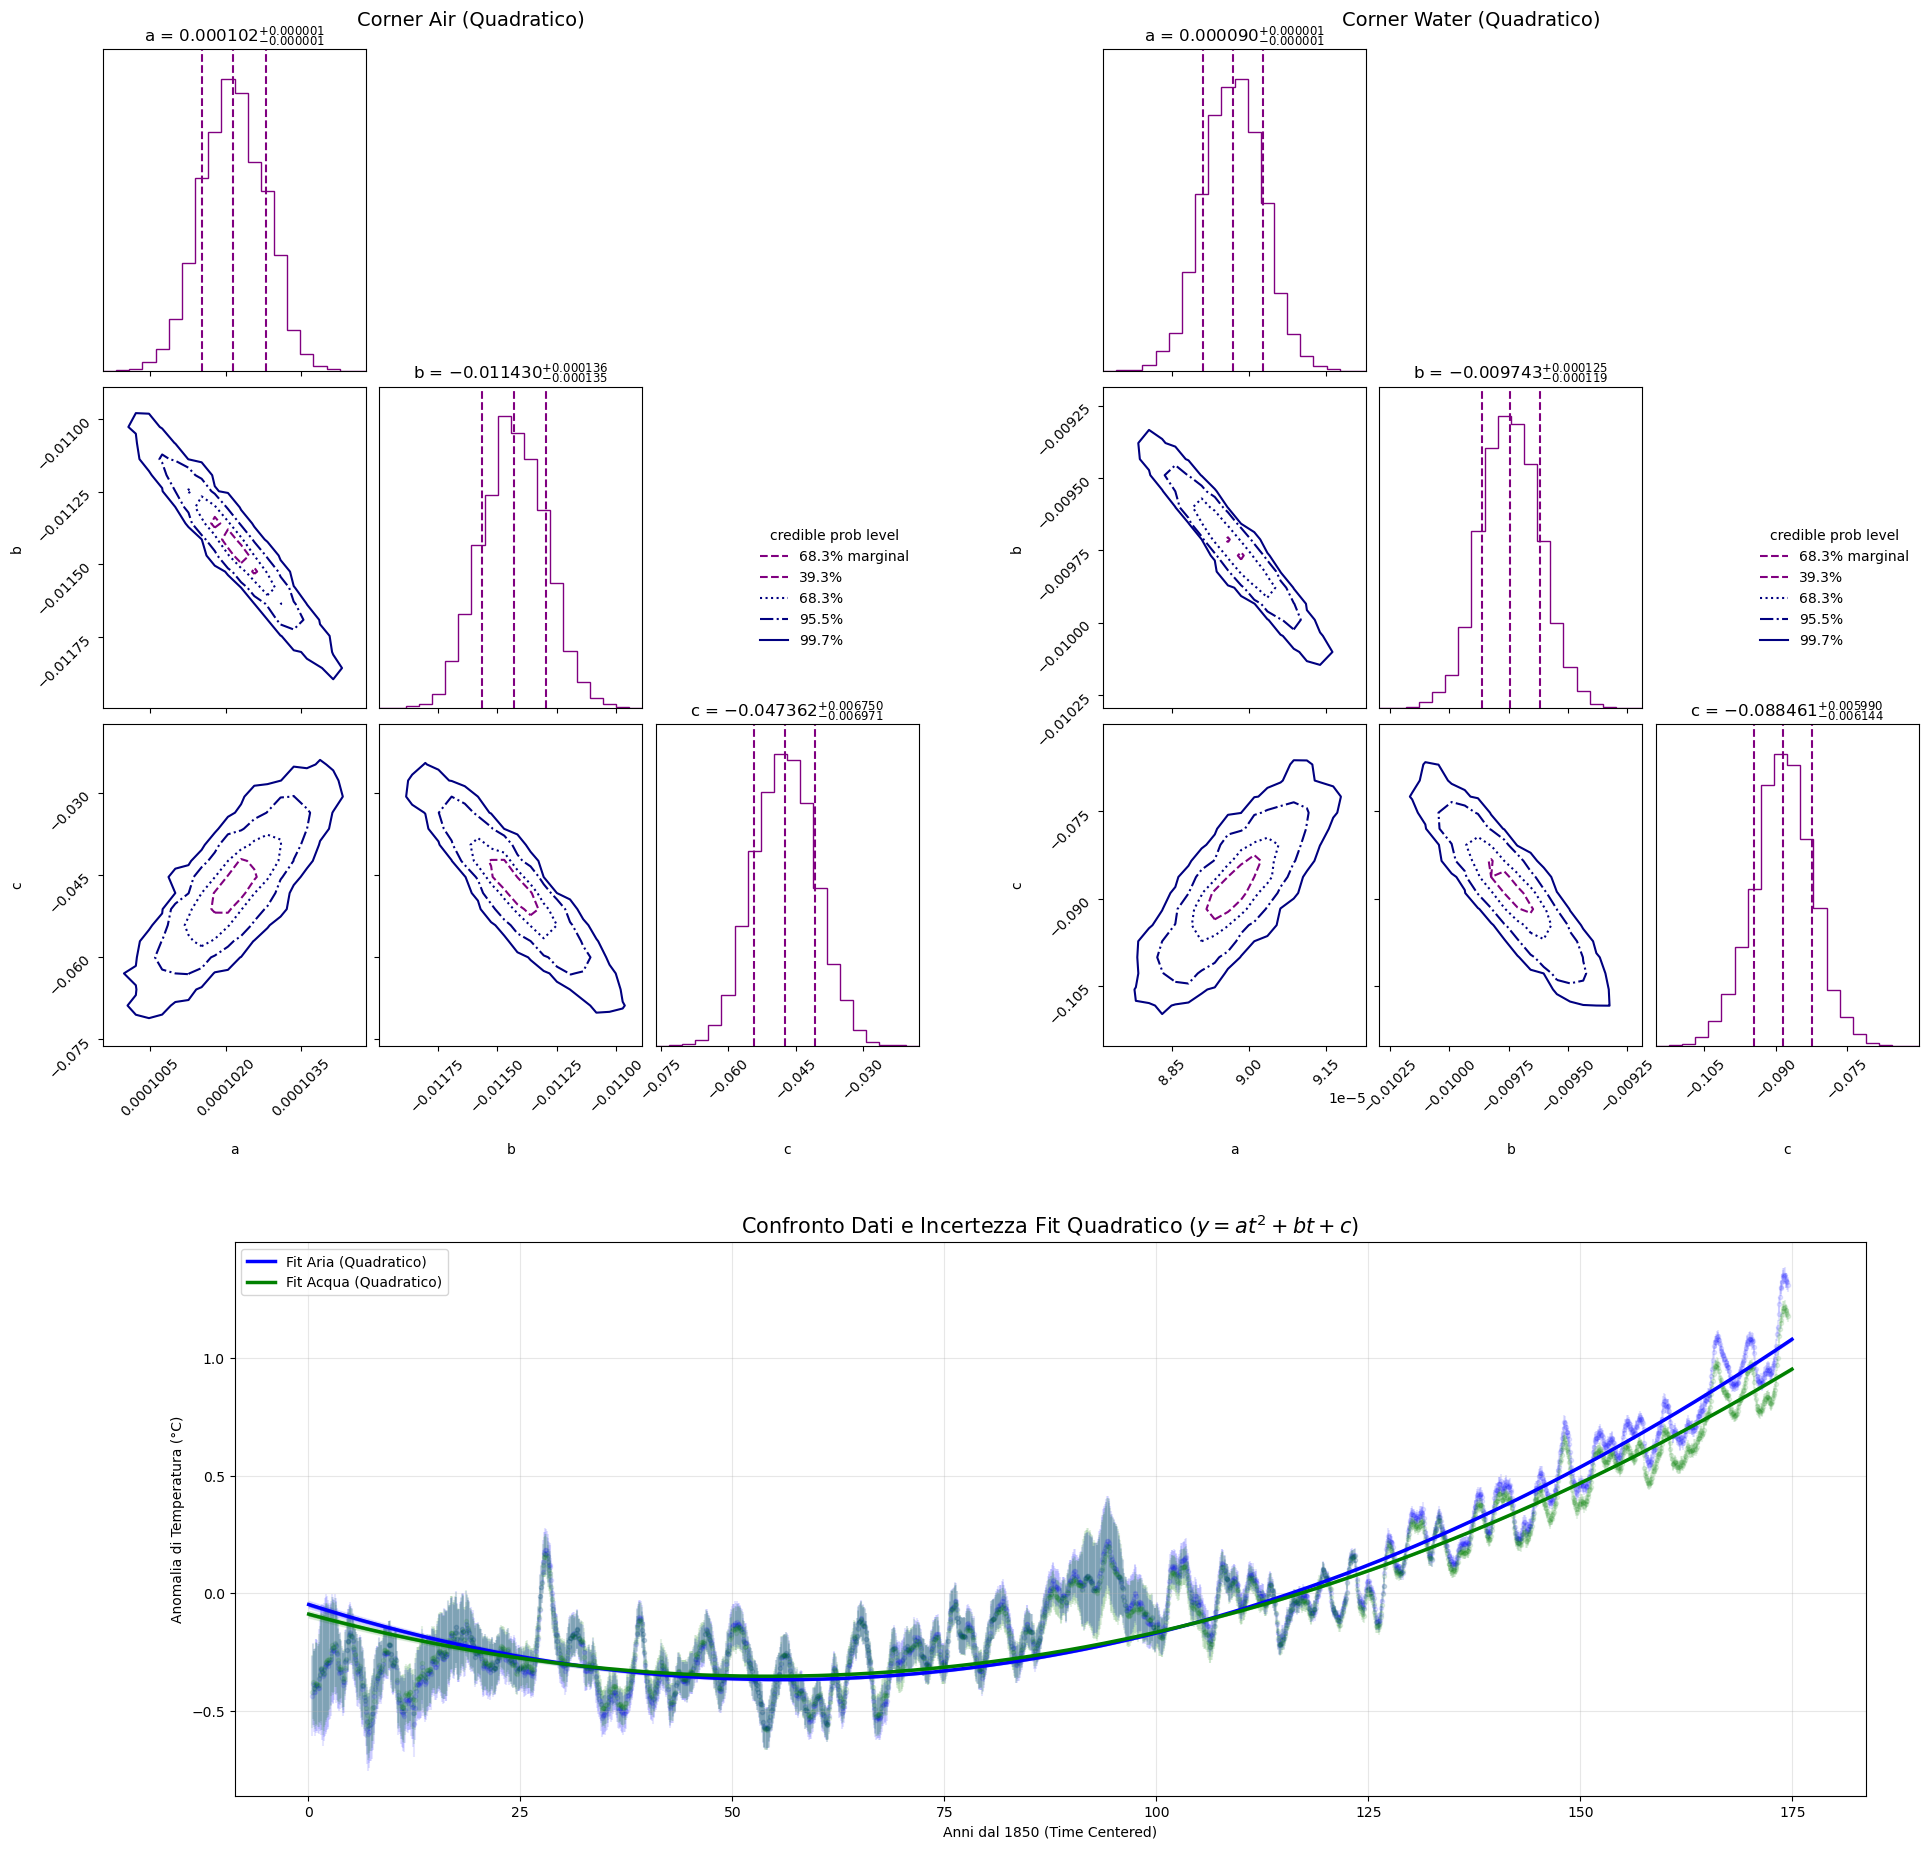

In [8]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid)
    
    for a, b, c in samples:
        band.add(a * t_grid**2 + b * t_grid + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Exponential fit

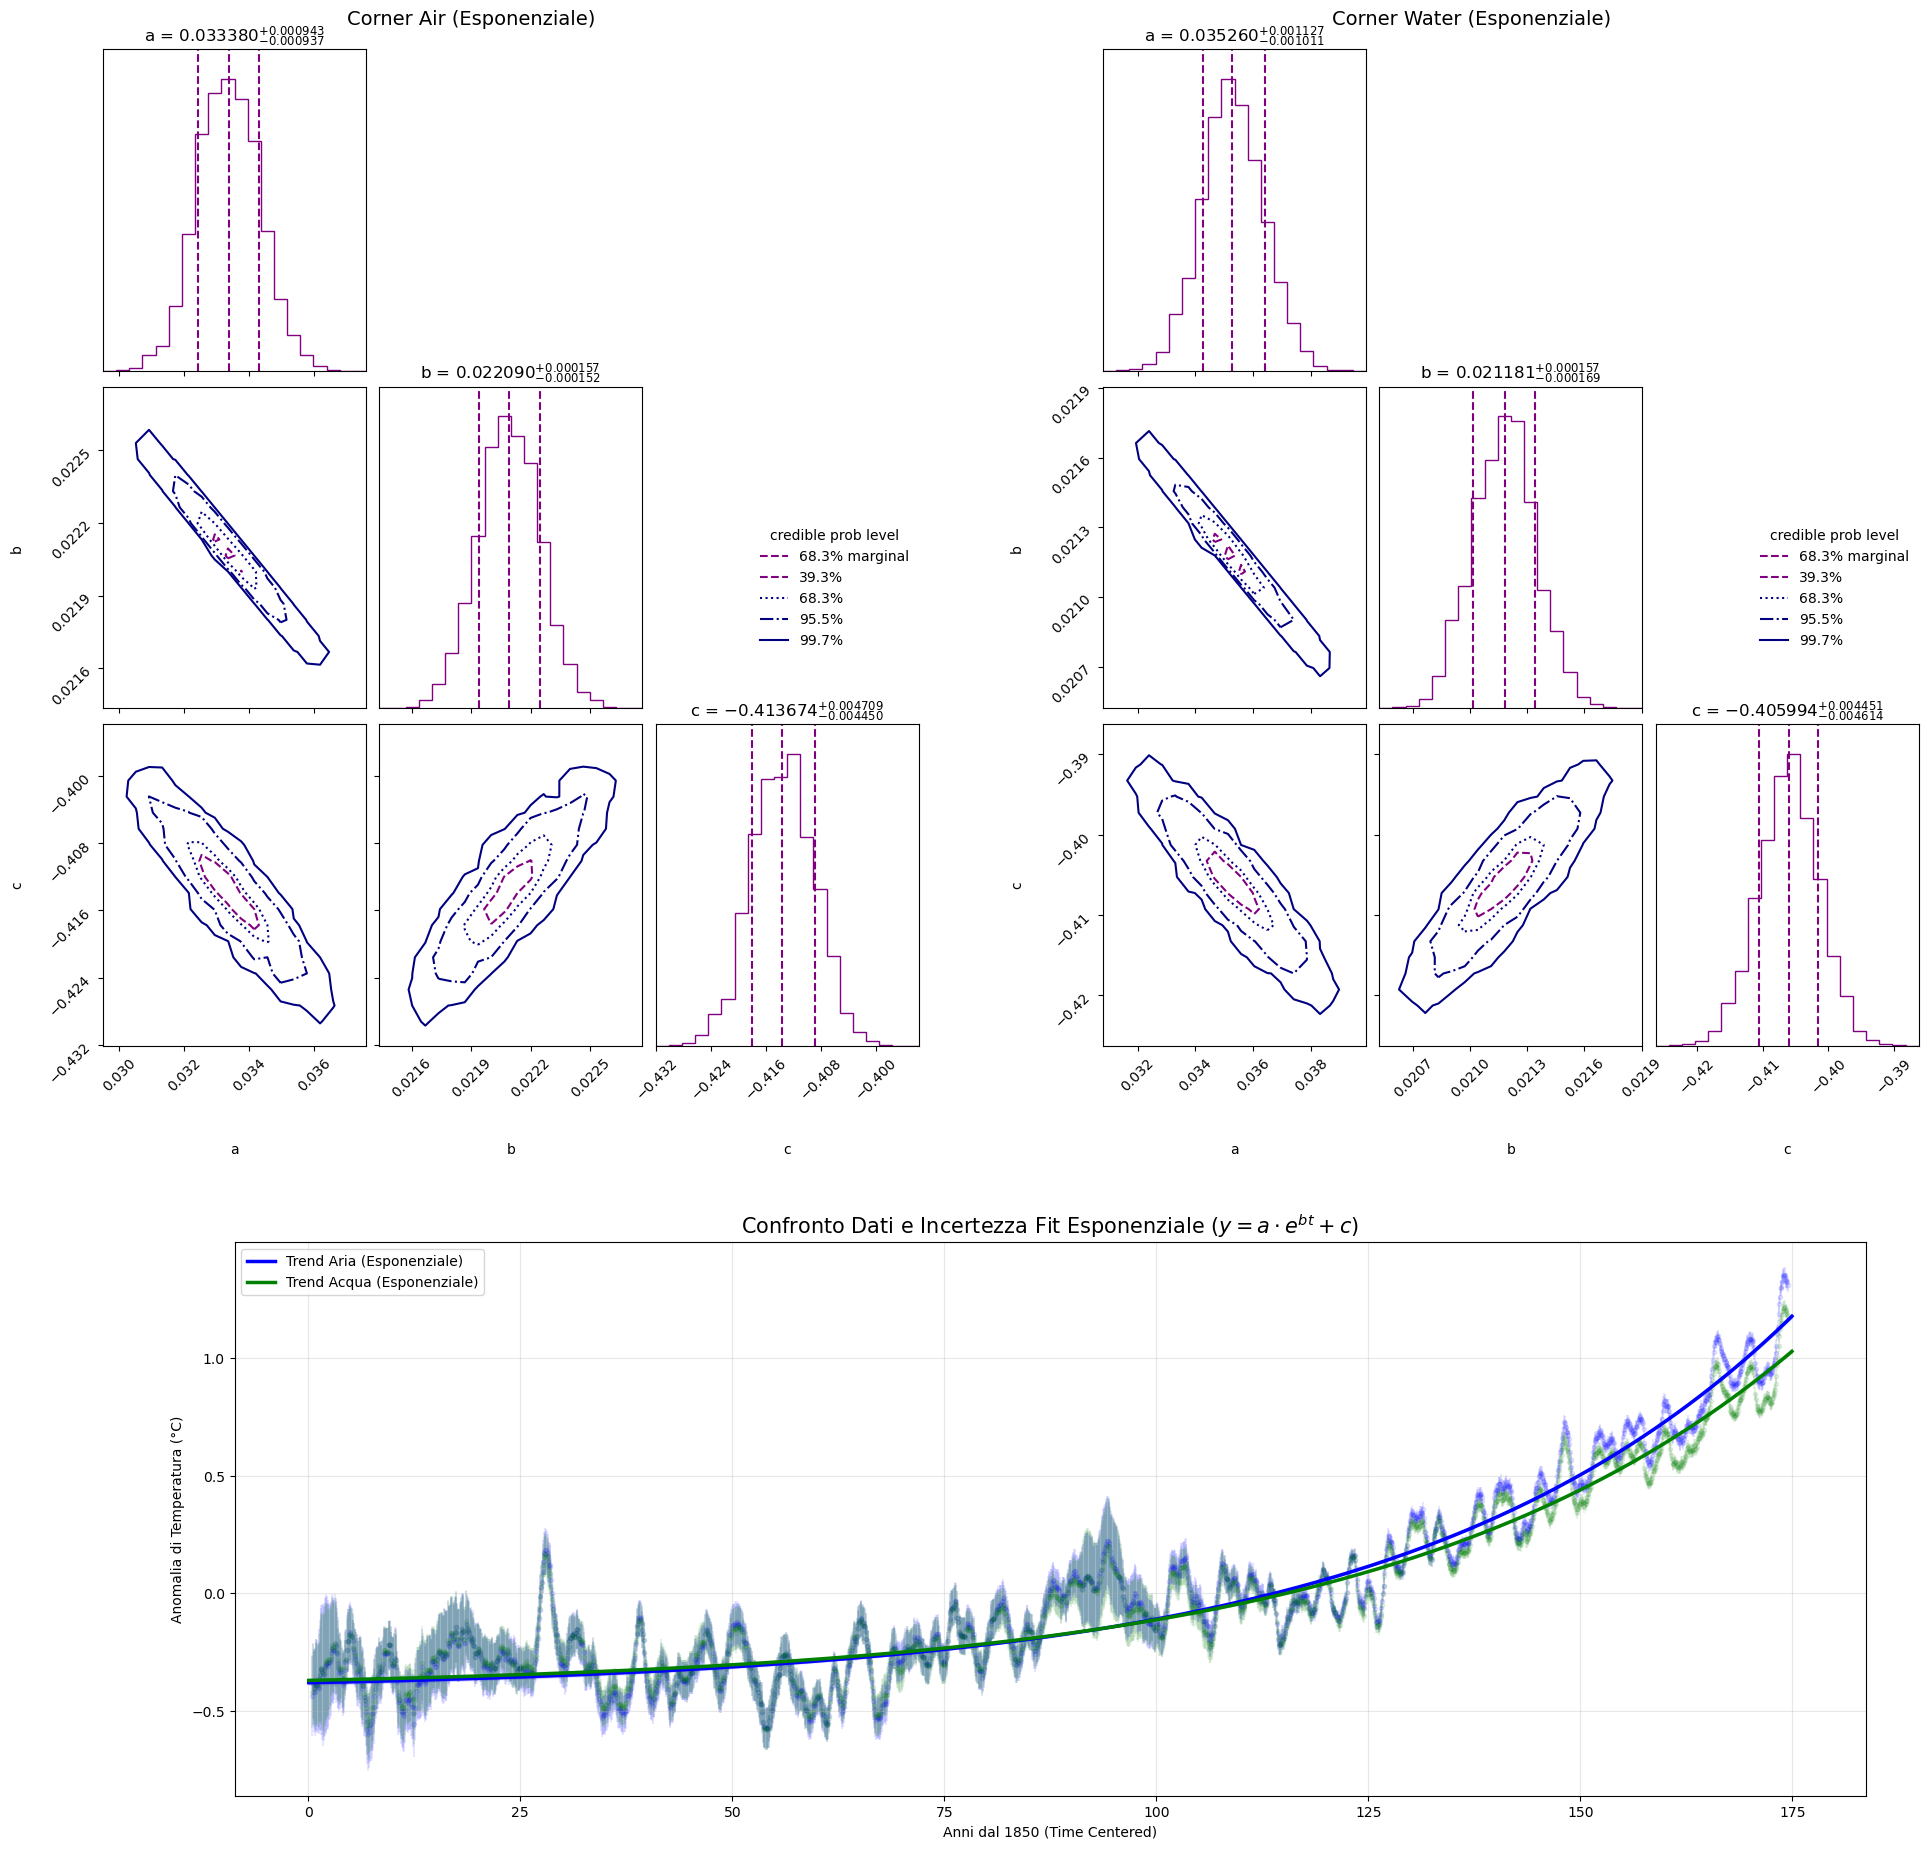

In [9]:
fig = plt.figure(figsize=(20, 19))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    for a, b, c in samples:
        band.add(a * np.exp(b * t_grid) + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

## Models comparison

In [10]:
dataset_labels = ['air', 'water']
model_labels = ['const', 'linear', 'quadratic', 'exponential']

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_const"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_linear"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = QUADRATICO): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_quadratic"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET (REF = ESPONENZIALE): {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_exponential"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")


--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81424.95 |         0.00
linear          |    -20205.74 |     61219.22
quadratic       |     -2172.43 |     79252.52
exponential     |     -1703.18 |     79721.77

--- CONFRONTO MODELLI PER DATASET (REF = COSTANTE): WATER ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -74219.58 |         0.00
linear          |    -18251.50 |     55968.07
quadratic       |     -1983.34 |     72236.23
exponential     |     -1709.45 |     72510.13

--- CONFRONTO MODELLI PER DATASET (REF = LINEARE): AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81424.95 |    -61219.22
linear          |    -20205.74 |         0.00
quadratic       |     -2172.43 |     18033.30
exponential     |     -1703.18 |  